Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
複数のデータフレームを横断的に処理する事例。3成分で相互平衡になっている。  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。初期濃度を変化させた複数の条件での実験結果を用い、全体を最適化できる速度定数を求めることを目標とする。  
3. 化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる。  
4. 作成した微分方程式を、数値解析可能な形式にする。  
5. **P0OptFit**（Optuna）で初期パラメータ p0 を探索し、最適な p0 で **ExpDataFit** により速度定数をフィッティングする。本ノートブックでは use_log_fit=True を用いる。  
6. 経時変化を図示する。  

残念ながら、df2の結果を再現できていない。複数のデータフレームを横断的に処理する実行例として掲載する。  

## 反応式を記載したcsvファイルを指定する  

In [2]:
file_path_rxn = './sample_data/ref5/sample_rxn_ref5.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [3]:
import time #15番目のセル、Optunaで初期値最適化後データにフィットさせる処理の計時  

import numpy as np
import pandas as pd

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read
from rxnfit.expdata_fit import ExpDataFit
from rxnfit.p0_opt_fit import P0OptFit


/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 反応速度式の作成

In [4]:
builded_rxnode = RxnODEbuild(file_path_rxn)

In [5]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 3
unique species: ['oXy', 'pXy', 'mXy']
rate constant: {'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}

=== debug info ===
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
order of args: ['t', 'oXy', 'pXy', 'mXy']
system of ODE: {'oXy': '-1/1*k1*oXy(t)+1/1*k2*pXy(t)-1/1*k3*oXy(t)+1/1*k4*mXy(t)', 'pXy': '1/1*k1*oXy(t)-1/1*k2*pXy(t)-1/1*k5*pXy(t)+1/1*k6*mXy(t)', 'mXy': '1/1*k3*oXy(t)-1/1*k4*mXy(t)+1/1*k5*pXy(t)-1/1*k6*mXy(t)'}


In [6]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


[Eq(Derivative(oXy(t), t), -k1*oXy(t) + k2*pXy(t) - k3*oXy(t) + k4*mXy(t)),
 Eq(Derivative(pXy(t), t), k1*oXy(t) - k2*pXy(t) - k5*pXy(t) + k6*mXy(t)),
 Eq(Derivative(mXy(t), t), k3*oXy(t) - k4*mXy(t) + k5*pXy(t) - k6*mXy(t))]

In [7]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

{'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}


[sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [8]:
df1 = pd.read_csv(f'./sample_data/ref5/ref5_df1.csv')
df2 = pd.read_csv(f'./sample_data/ref5/ref5_df2.csv')
df3 = pd.read_csv(f'./sample_data/ref5/ref5_df3.csv')
df4 = pd.read_csv(f'./sample_data/ref5/ref5_df4.csv')

# plot_datasets で名前指定する場合、df.attrs['name'] を設定（省略可）
df1.attrs['name'] = 'df1'
df2.attrs['name'] = 'df2'
df3.attrs['name'] = 'df3'
df4.attrs['name'] = 'df4'

expdata_read([df1, df2, df3, df4])  # 複数データフレームのリストを渡すとまとめて読み込み可能

[([array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ])],
  [array([0.999, 0.95 , 0.846, 0.738, 0.632, 0.434, 0.19 , 0.175, 0.187]),
   array([0.   , 0.048, 0.148, 0.241, 0.328, 0.478, 0.632, 0.627, 0.602]),
   array([0.001, 0.002, 0.006, 0.021, 0.04 , 0.088, 0.178, 0.198, 0.211])]),
 ([array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46])],
  [array([0.005, 0.006, 0.026, 0.02 , 0.046, 0.089, 0.114, 0.144, 0.174]),
   array([0.986, 0.973, 0.933, 0.918, 0.86 , 0.768, 0.709, 0.647, 0.609]),
   array([0.009, 0.021, 0.041, 0.062, 0.094, 0.143, 0.177, 0.209, 0.217])]),
 ([array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ])],
  [array([0.001, 0.00

### フィッティング  
P0OptFit に RxnODEbuild のインスタンスと df_list を渡し、Optuna で初期値 p0 を最適化したうえで ExpDataFit によりフィッティングする。  


In [ ]:
t_cpu_start = time.process_time() # CPU時間計測

# P0OptFit: RxnODEbuild インスタンスと df_list を渡す（他は最小限）
# CPU time: method="RK45"で00:17:14、method="LSODA"で00:11:44
opt = P0OptFit(builded_rxnode, [df1, df2, df3, df4], method="LSODA", seed=123)
result_dict, fit_metrics = opt.optimize(n_trials=10)

# プロット用に最適 p0 で ExpDataFit を1回実行し、config を取得
keys = builded_rxnode.get_symbolic_rate_const_keys()
p0_best = [result_dict[k][1] for k in keys]
t_range = (0, max(float(df.iloc[:, 0].max()) for df in [df1, df2, df3, df4]))
fit_sci = ExpDataFit(builded_rxnode, [df1, df2, df3, df4], t_range)
fit_sci.run_fit(p0_best, use_log_fit=True, lower_bound=1e-10)

t_cpu_end = time.process_time()
elapsed = t_cpu_end - t_cpu_start
h, r = divmod(int(elapsed), 3600)
m, s = divmod(r, 60)
print(f"CPU time: {h:02d}:{m:02d}:{s:02d}")

[I 2026-05-04 21:19:37,847] A new study created in memory with name: no-name-560f6aae-15b4-4df9-a399-9922bab1b44e
  0%|          | 0/10 [00:00<?, ?it/s]

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


Best trial: 0. Best value: 0.136217:  10%|█         | 1/10 [00:20<03:02, 20.31s/it]

[I 2026-05-04 21:19:58,162] Trial 0 finished with value: 0.13621697029705884 and parameters: {'k1': 0.09219170692219454, 'k2': 7.267639045471199e-06, 'k3': 1.855728918810948e-06, 'k4': 0.003259475273606692, 'k5': 0.15656320308475058, 'k6': 0.00017024117230719408}. Best is trial 0 with value: 0.13621697029705884.
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


Best trial: 0. Best value: 0.136217:  20%|██        | 2/10 [01:49<08:08, 61.02s/it]

...

[W 2026-05-04 21:25:00,904] Trial 7 failed with parameters: {'k1': 1.4888632772816035e-05, 'k2': 0.00014068964038260946, 'k3': 4.603536372243008, 'k4': 3.195609134986815e-06, 'k5': 0.0006766165908628813, 'k6': 71.71299425399306} because of the following error: RuntimeError('run_fit did not converge: ABNORMAL: ').
Traceback (most recent call last):
  File "/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/mt_oh/work/rxnfit/examples/../src/rxnfit/p0_opt_fit.py", line 186, in _objective
    raise RuntimeError(
RuntimeError: run_fit did not converge: ABNORMAL: 
[W 2026-05-04 21:25:00,907] Trial 7 failed with value None.
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


Best trial: 3. Best value: 0.136217:  90%|█████████ | 9/10 [06:07<00:39, 39.08s/it]

[I 2026-05-04 21:25:45,185] Trial 8 finished with value: 0.13621697028178398 and parameters: {'k1': 0.0015662143278100168, 'k2': 0.013456907204414215, 'k3': 1.6080022788912947e-07, 'k4': 1.834036629034631, 'k5': 0.010730038595535289, 'k6': 0.0028227997133781976}. Best is trial 3 with value: 0.1362169702788233.
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


Best trial: 3. Best value: 0.136217: 100%|██████████| 10/10 [07:24<00:00, 44.42s/it]


[W 2026-05-04 21:27:02,063] Trial 9 failed with parameters: {'k1': 2.6769381543629093e-05, 'k2': 1.0995320430205856e-05, 'k3': 0.0001479865038703521, 'k4': 0.06501411542010016, 'k5': 5.6828791153785625, 'k6': 0.0012712277796716812} because of the following error: RuntimeError('run_fit did not converge: ABNORMAL: ').
Traceback (most recent call last):
  File "/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/mt_oh/work/rxnfit/examples/../src/rxnfit/p0_opt_fit.py", line 186, in _objective
    raise RuntimeError(
RuntimeError: run_fit did not converge: ABNORMAL: 
[W 2026-05-04 21:27:02,072] Trial 9 failed with value None.
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


=== Time-course plot ===


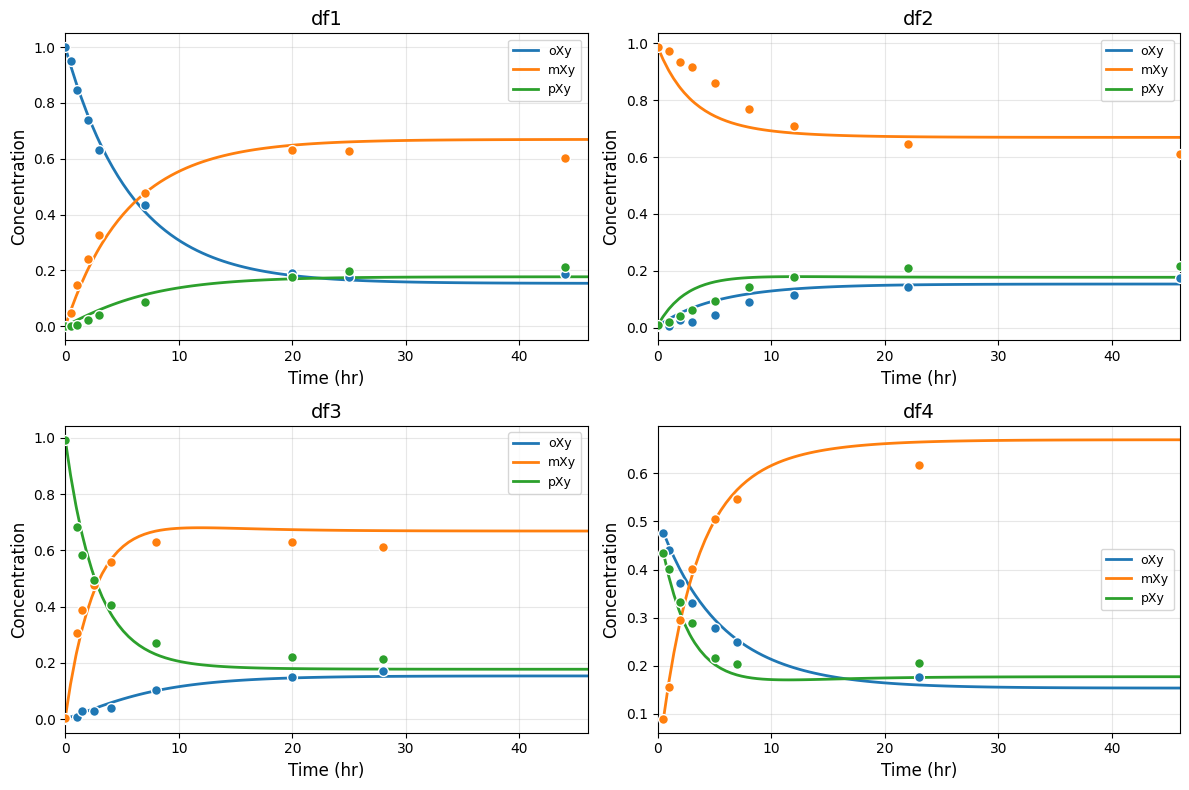


=== Concentration at the final time point ===
df1:
  oXy: 0.153910
  mXy: 0.668916
  pXy: 0.177174
df2:
  oXy: 0.153511
  mXy: 0.669210
  pXy: 0.177279
df3:
  oXy: 0.153322
  mXy: 0.668567
  pXy: 0.177111
df4:
  oXy: 0.153850
  mXy: 0.669743
  pXy: 0.177407


In [10]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(
    expdata_df=[df1, df2, df3, df4], 
    species=['oXy', 'mXy', 'pXy'], 
    subplot_layout=(2,2)
    )

In [11]:
# 最適化された k1–k6 と metrics の再表示
keys = builded_rxnode.get_symbolic_rate_const_keys()
print("Fitted rate constants:")
for k in keys:
    p0_val, fitted_val = result_dict[k]
    print(f"  {k}: p0={p0_val:.6g}, fitted={fitted_val:.6g}")
print("\nFit metrics:")
for name, val in fit_metrics.items():
    print(f"  {name}: {val:.6g}")

Fitted rate constants:
  k1: p0=0.00206782, fitted=0.0208643
  k2: p0=0.00208102, fitted=0.0127112
  k3: p0=0.0220805, fitted=0.123445
  k4: p0=3.12117, fitted=0.0297497
  k5: p0=0.175612, fitted=0.283859
  k6: p0=0.0128895, fitted=0.0737738

Fit metrics:
  rss: 0.136217
  tss: 6.63985
  r2: 0.979485
